# Teen Mental Health Analysis

This notebook explores the relationship between social media usage and teen depression, then builds classification models to predict `depression_label`.

## Goals
- Understand the structure and quality of the dataset
- Explore the strongest signals linked to depression
- Build reproducible baseline models
- Compare models with metrics that account for class imbalance

> Note: the target class is highly imbalanced, so accuracy alone is not enough. We will pay closer attention to recall, F1-score, ROC AUC, and average precision.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path('Teen_Mental_Health_Dataset.csv')


def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    enriched = df.copy()
    enriched['mental_health_score'] = (
        enriched['stress_level'] + enriched['anxiety_level'] + enriched['addiction_level']
    )
    enriched['night_screen_exposure'] = (
        enriched['daily_social_media_hours'] + enriched['screen_time_before_sleep']
    )
    enriched['screen_sleep_ratio'] = (
        enriched['daily_social_media_hours'] / enriched['sleep_hours'].clip(lower=0.1)
    )
    return enriched


data = load_data(DATA_PATH)
data = add_features(data)

print(f'Shape: {data.shape}')
data.head()

Shape: (1200, 16)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score,night_screen_exposure,screen_sleep_ratio
0,14,male,7.900,Instagram,7.400,2.900,3.010,1.500,low,2,2,1,0,5,10.800,1.068
1,19,female,1.900,TikTok,8.000,2.900,3.220,0.800,high,8,1,10,0,19,4.800,0.237
2,17,female,1.300,Instagram,7.600,0.500,3.920,0.000,high,2,4,2,0,8,1.800,0.171
3,15,male,7.400,TikTok,6.900,1.600,3.480,0.800,medium,1,7,9,0,17,9.000,1.072
4,15,female,4.700,Both,4.900,3.000,2.370,1.400,medium,3,5,2,0,10,7.700,0.959


## Data Quality Check

We start by reviewing data types, missing values, and the target distribution. This helps confirm whether the dataset is ready for modeling and whether we need to account for imbalance.

In [3]:
summary = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'missing_values': data.isna().sum(),
    'missing_pct': (data.isna().mean() * 100).round(2)
})

summary

,dtype,missing_values,missing_pct
age,int64,0,0.000
gender,object,0,0.000
daily_social_media_hours,float64,0,0.000
platform_usage,object,0,0.000
sleep_hours,float64,0,0.000
screen_time_before_sleep,float64,0,0.000
academic_performance,float64,0,0.000
physical_activity,float64,0,0.000
social_interaction_level,object,0,0.000
stress_level,int64,0,0.000


depression_label
0   0.974
1   0.026
Name: proportion, dtype: float64


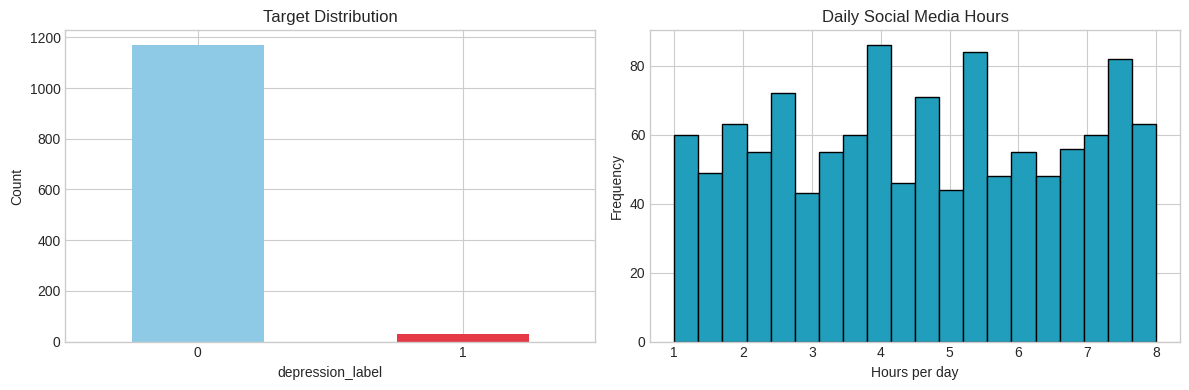

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(
    data['depression_label']
    .value_counts()
    .sort_index()
    .plot(kind='bar', ax=axes[0], color=['#8ecae6', '#e63946'])
)
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('depression_label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(data['daily_social_media_hours'], bins=20, color='#219ebc', edgecolor='black')
axes[1].set_title('Daily Social Media Hours')
axes[1].set_xlabel('Hours per day')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
print(data['depression_label'].value_counts(normalize=True).rename('proportion').round(3))

## Exploratory Analysis

Correlation is only a starting point, but it gives a quick view of which numeric variables move most closely with the target.

Top correlations with depression_label


,correlation
screen_sleep_ratio,0.293
sleep_hours,-0.191
mental_health_score,0.187
daily_social_media_hours,0.175
stress_level,0.170
anxiety_level,0.170
night_screen_exposure,0.158
physical_activity,-0.018


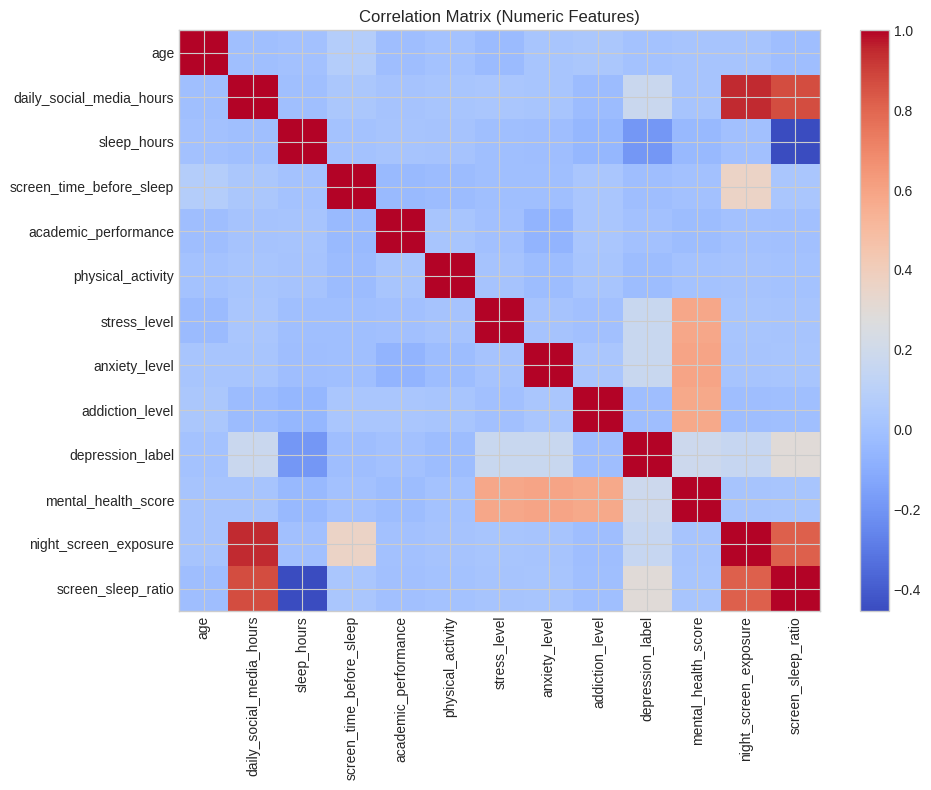

In [5]:
numeric_data = data.select_dtypes(include='number')
correlation_matrix = numeric_data.corr()

target_correlation = (
    correlation_matrix['depression_label']
    .drop('depression_label')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_yticklabels(correlation_matrix.columns)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.colorbar(heatmap, ax=ax)
plt.tight_layout()

print('Top correlations with depression_label')
display(target_correlation.head(8).to_frame('correlation'))

## Modeling Approach

To keep the workflow reproducible, we use a single preprocessing pipeline:
- numeric features: median imputation + scaling
- categorical features: most frequent imputation + one-hot encoding

We compare three models:
- Logistic Regression
- Logistic Regression with `class_weight='balanced'`
- Random Forest with `class_weight='balanced'`

Cross-validation gives a more reliable comparison than a single train/test split.

In [6]:
X = data.drop(columns='depression_label')
y = data['depression_label']

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
            ]),
            categorical_features,
        ),
    ]
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Logistic Regression (Balanced)': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = []
for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)
    cv_results.append({
        'model': model_name,
        **{metric: scores[f'test_{metric}'].mean() for metric in scoring}
    })

cv_results = pd.DataFrame(cv_results).sort_values(by=['average_precision', 'f1'], ascending=False)
cv_results.round(3)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
2,Random Forest (Balanced),0.993,1.000,0.743,0.842,0.999,0.984
0,Logistic Regression,0.982,0.790,0.452,0.558,0.985,0.764
1,Logistic Regression (Balanced),0.951,0.326,0.833,0.468,0.983,0.712


Selected model: Random Forest (Balanced)
              precision    recall  f1-score   support

           0      0.992     1.000     0.996       234
           1      1.000     0.667     0.800         6

    accuracy                          0.992       240
   macro avg      0.996     0.833     0.898       240
weighted avg      0.992     0.992     0.991       240



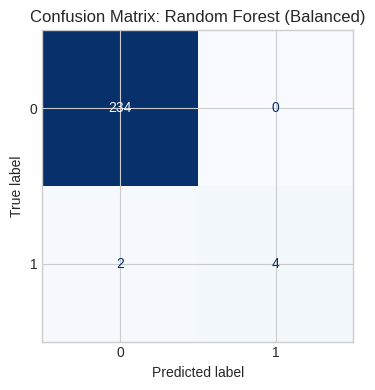

In [7]:
selected_model_name = cv_results.iloc[0]['model']
selected_model = models[selected_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', selected_model),
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print(f'Selected model: {selected_model_name}')
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix: {selected_model_name}')
plt.tight_layout()

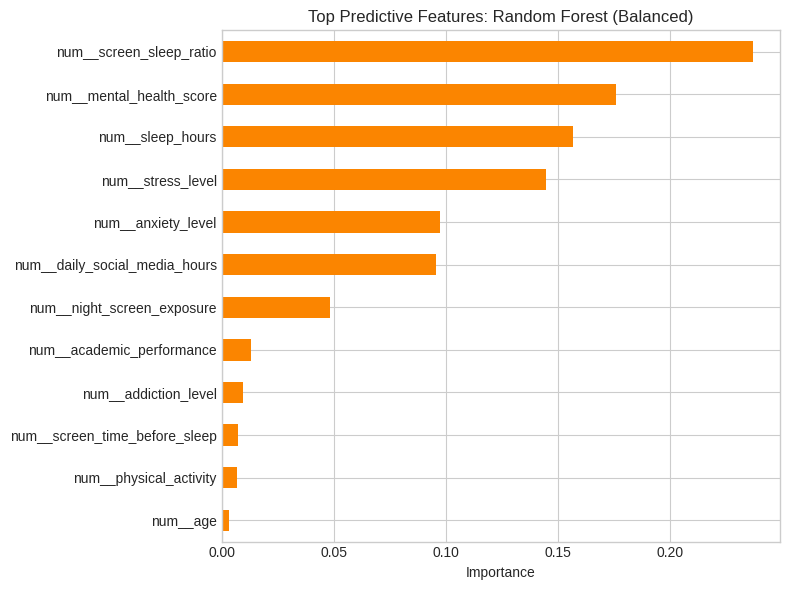

In [8]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
model = final_pipeline.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importance = pd.Series(model.feature_importances_, index=feature_names)
else:
    importance = pd.Series(model.coef_[0], index=feature_names).abs()

importance.sort_values(ascending=False).head(12).plot(
    kind='barh',
    figsize=(8, 6),
    color='#fb8500'
)
plt.title(f'Top Predictive Features: {selected_model_name}')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()

## Conclusion

This cleaned workflow shows a more reproducible modeling process than the original draft:

- The dataset is strongly imbalanced, so recall and precision for the positive class matter more than raw accuracy.
- Stress, anxiety, addiction, and screen-related features appear among the strongest predictive signals.
- On this dataset, the top-performing model on cross-validation is selected automatically rather than by manual inspection.

### Portfolio Takeaway
This notebook is now structured to be easier to review on GitHub: clear objectives, cleaner code, reproducible preprocessing, and conclusions that are tied directly to the reported metrics.